# House Keeping

In [1]:
import sys
import os
sys.path.append('/scratch_net/ken/radjoe/Projects/Experiments/SAMEXP/')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from scipy.stats import ttest_ind, mannwhitneyu

from helper_func.analyis_helper import vis_image, clean_df
from datasets.datasets import MRIDataset

In [3]:
# Sharpness functions 
def display_img(path1, path2):
    valid_files = [i for i in os.listdir(path1) if i.endswith('.npy')]
    path_files = [i for i in os.listdir(path2) if i.endswith('.npy')]
    for i in range(len(valid_files)):
        img1 = vis_image(os.path.join(path1, valid_files[i]))
        img2 = vis_image(os.path.join(path2, path_files[i]))

        fig, ax = plt.subplots(1, 2)
        ax[0].imshow(img1[80])
        ax[1].imshow(img2[80])
        plt.show()

def sharpness_laplacian_variance(img):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    return lap.var()

def sharpness_tenengrad(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.sqrt(gx**2 + gy**2).mean()

def sharpness_fft(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20*np.log(np.abs(fshift))
    return np.mean(magnitude_spectrum)

def mean_laplacian_sharpness(path):
    valid_files = [i for i in os.listdir(path) if i.endswith('.npy')]
    sharpness = []
    for i in range(len(valid_files)):
        img = vis_image(os.path.join(path, valid_files[i]))
        img = img[80]
        if len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            # Normalize dtype
        if img.dtype != np.uint8:
            img = cv2.normalize(img.astype('float32'), None, 0, 255, cv2.NORM_MINMAX)
            img = img.astype(np.uint8)
        lap_var = sharpness_laplacian_variance(img)
        sharpness.append(lap_var)
    sharpness = np.array(sharpness)
    mean_sharpness = sharpness.mean()
    return valid_files, sharpness, mean_sharpness

def mean_tenen_sharpness(path):
    valid_files = [i for i in os.listdir(path) if i.endswith('.npy')]
    sharpness = []
    for i in range(len(valid_files)):
        img = vis_image(os.path.join(path, valid_files[i]))
        img = img[80]
        if len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            # Normalize dtype
        if img.dtype != np.uint8:
            img = cv2.normalize(img.astype('float32'), None, 0, 255, cv2.NORM_MINMAX)
            img = img.astype(np.uint8)
        lap_var = sharpness_tenengrad(img)
        sharpness.append(lap_var)
    sharpness = np.array(sharpness)
    mean_sharpness = sharpness.mean()
    return valid_files, sharpness, mean_sharpness

def mean_fft_sharpness(path):
    valid_files = [i for i in os.listdir(path) if i.endswith('.npy')]
    sharpness = []
    for i in range(len(valid_files)):
        img = vis_image(os.path.join(path, valid_files[i]))
        img = img[80]
        if len(img.shape) == 3 and img.shape[2] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            # Normalize dtype
        if img.dtype != np.uint8:
            img = cv2.normalize(img.astype('float32'), None, 0, 255, cv2.NORM_MINMAX)
            img = img.astype(np.uint8)
        lap_var = sharpness_fft(img)
        sharpness.append(lap_var)
    sharpness = np.array(sharpness)
    mean_sharpness = sharpness.mean()
    return valid_files, sharpness, mean_sharpness

In [4]:
# Check Global Stats
from scipy.stats import entropy

def compute_image_entropy(image, bins=256):
    hist, _ = np.histogram(image.flatten(), bins=bins, density=True)
    hist += 1e-8  # to avoid log(0)
    return entropy(hist, base=2)


def compute_std(image):
    std = np.std(image)
    # mean = np.mean(image)
    return std

def mean_image_entropy(path):
    valid_files = [i for i in os.listdir(path) if i.endswith('.npy')]
    sharpness = []
    for i in range(len(valid_files)):
        img = vis_image(os.path.join(path, valid_files[i]))
        lap_var = compute_image_entropy(img)
        sharpness.append(lap_var)
    sharpness = np.array(sharpness)
    mean_sharpness = sharpness.mean()
    return valid_files, sharpness, mean_sharpness

def mean_image_std(path):
    valid_files = [i for i in os.listdir(path) if i.endswith('.npy')]
    sharpness = []
    for i in range(len(valid_files)):
        img = vis_image(os.path.join(path, valid_files[i]))
        lap_var = compute_std(img)
        sharpness.append(lap_var)
    sharpness = np.array(sharpness)
    mean_sharpness = sharpness.mean()
    return valid_files, sharpness, mean_sharpness

In [24]:
SSA_image_path = '/scratch_net/ken/radjoe/Preprocess_BraTS2023_SSA_Training/images_UNN'
GLI_image_path = '/scratch_net/ken/radjoe/BraTS/Validation/images_UNN'

SSA_label_path = '/scratch_net/ken/radjoe/Preprocess_BraTS2023_SSA_Training/labels_UNN'
GLI_label_path = '/scratch_net/ken/radjoe/BraTS/Validation/labels_UNN'

In [25]:
SSA_dataset = MRIDataset(SSA_image_path, SSA_label_path)
GLI_dataset = MRIDataset(GLI_image_path, GLI_label_path)

## Visualize

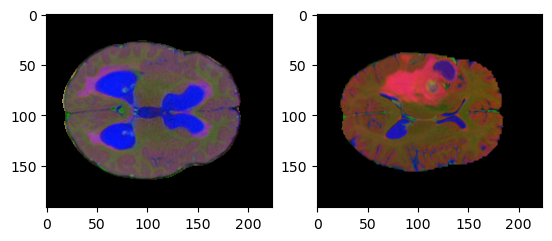

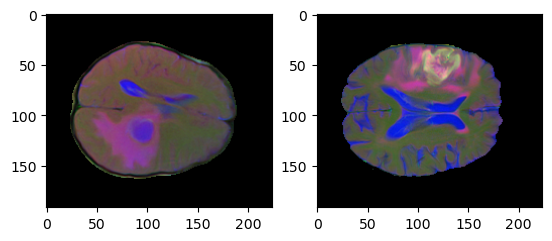

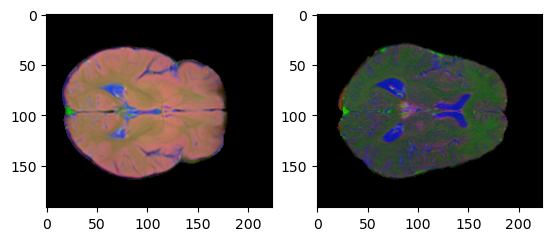

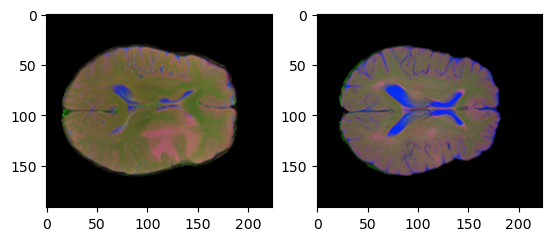

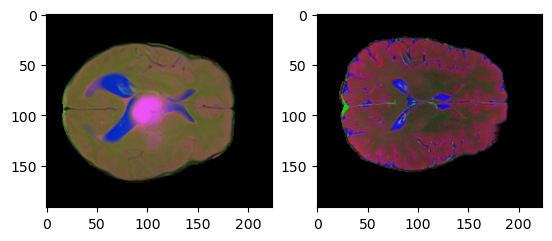

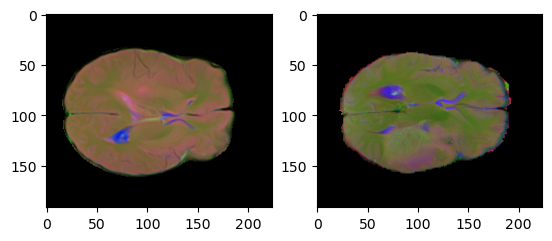

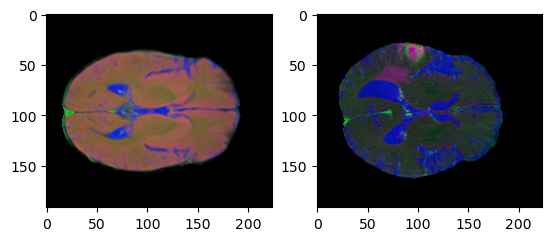

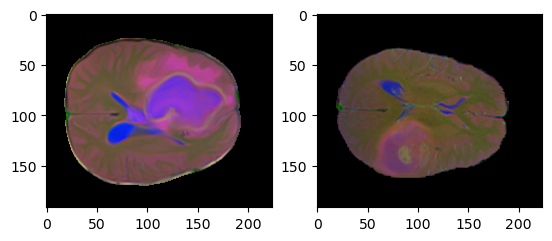

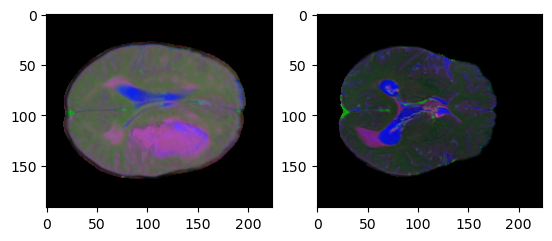

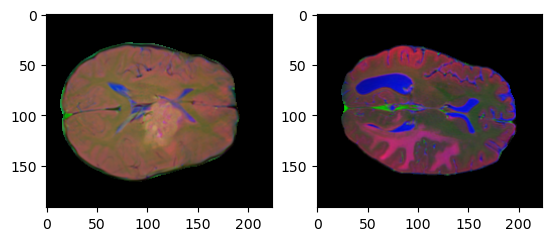

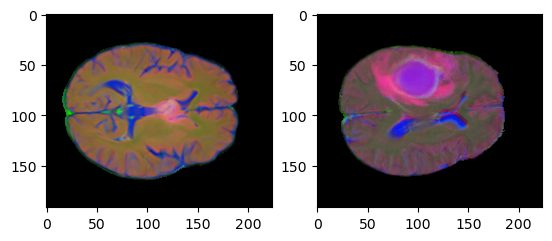

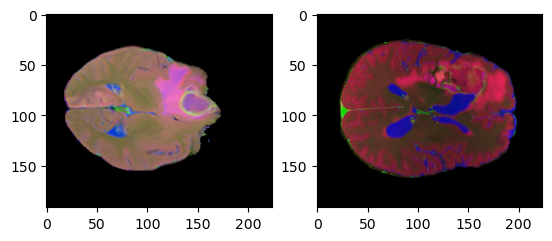

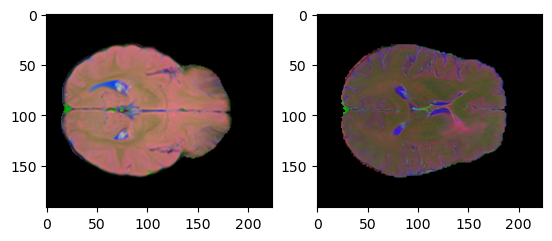

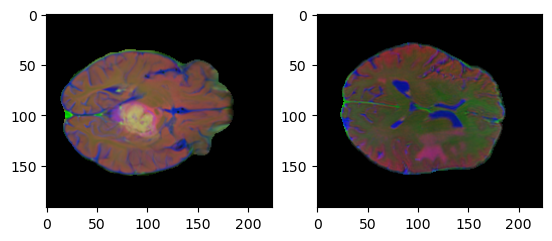

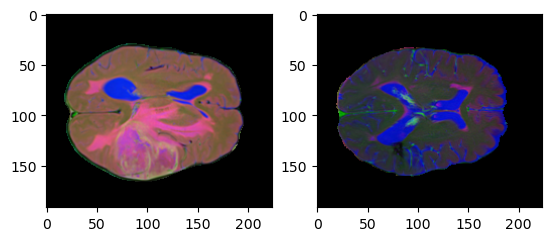

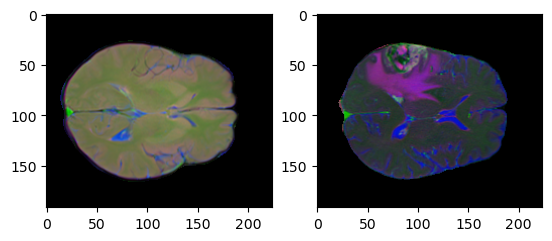

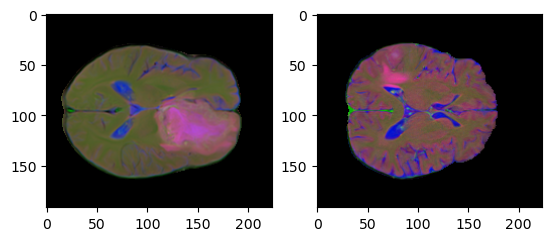

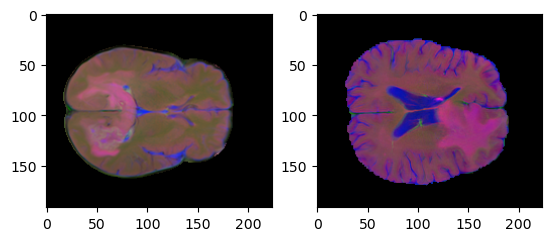

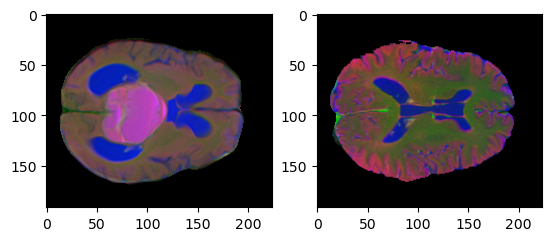

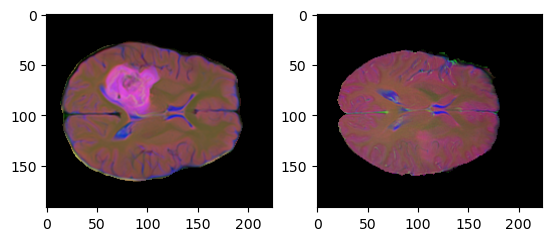

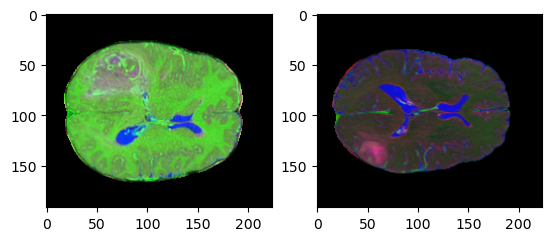

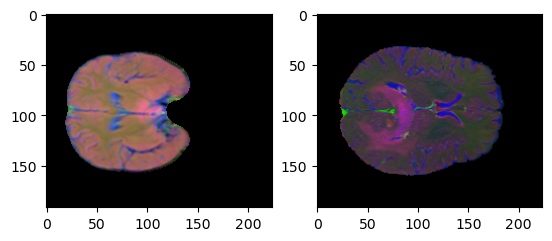

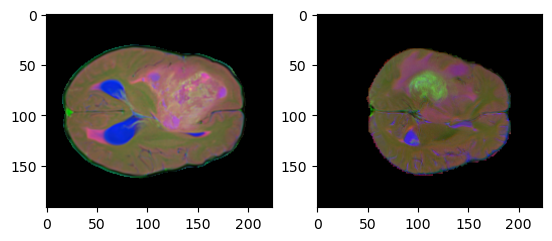

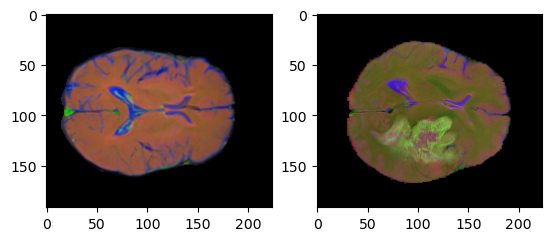

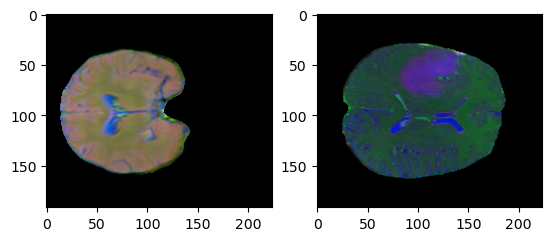

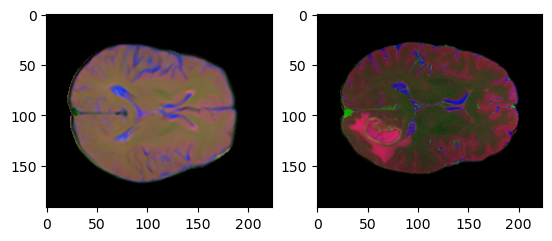

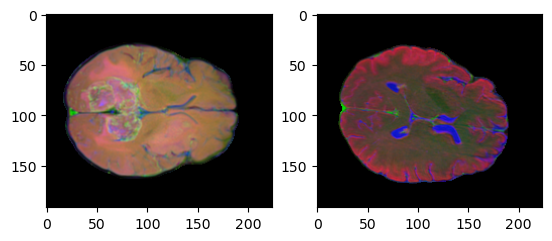

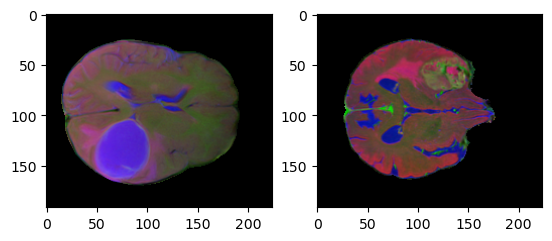

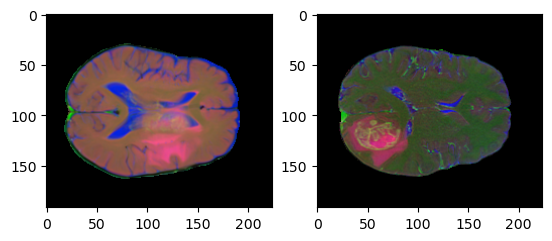

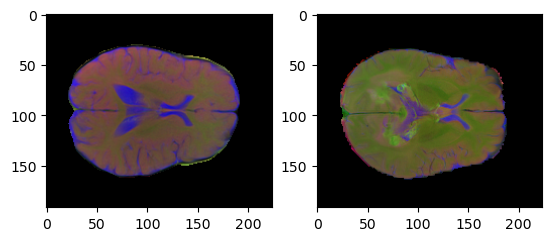

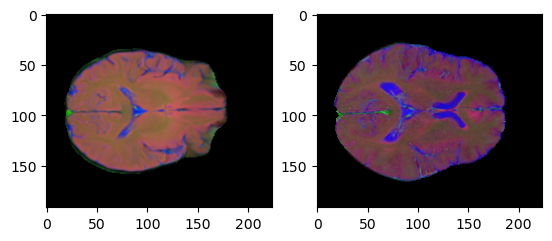

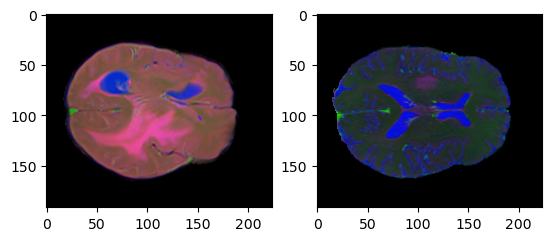

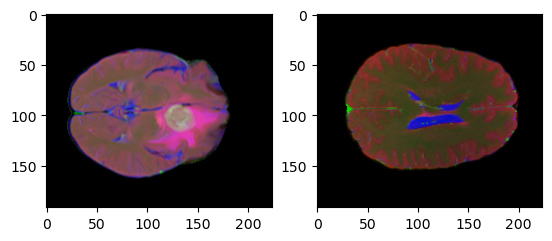

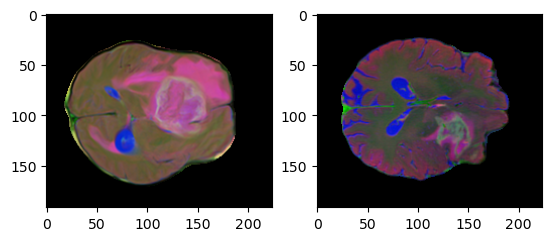

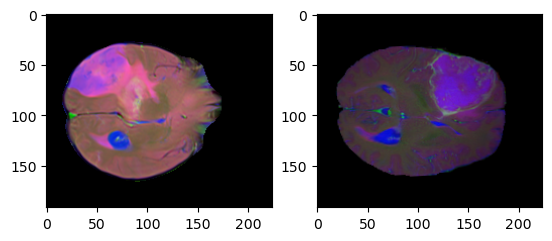

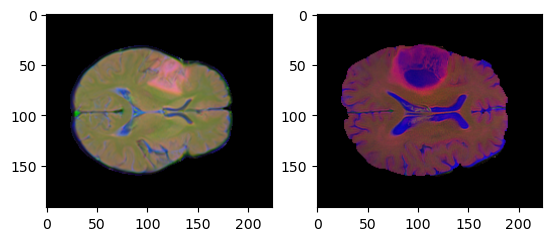

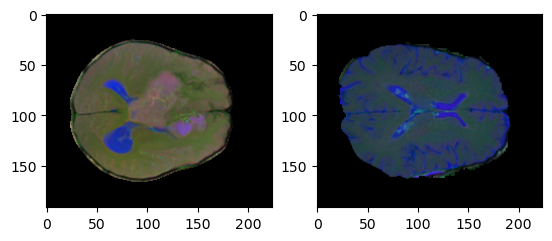

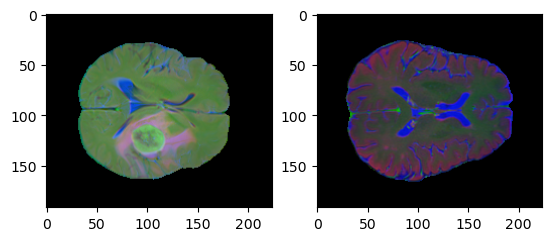

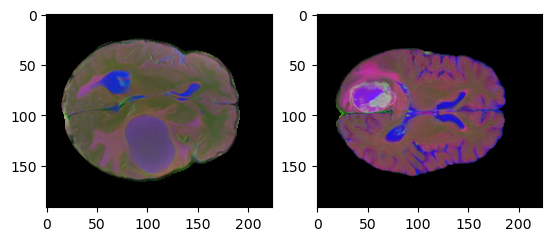

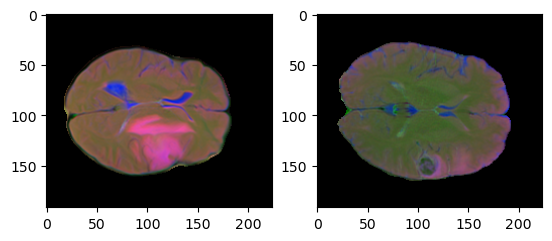

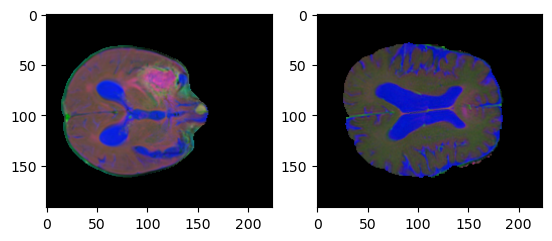

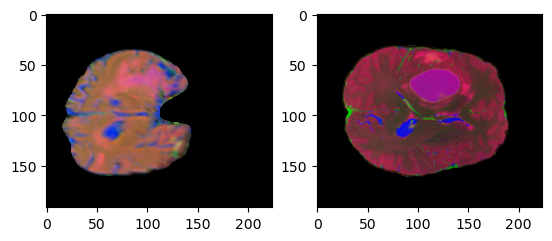

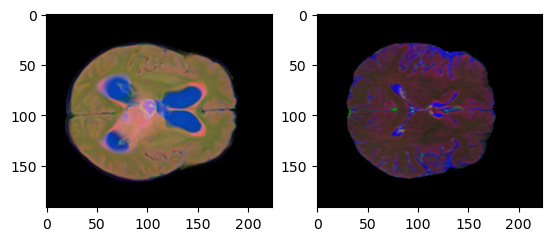

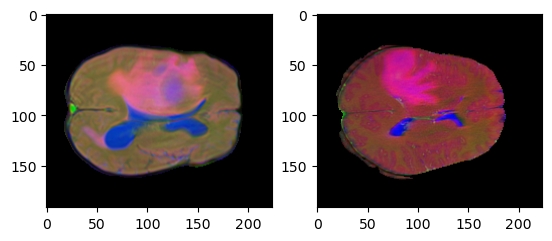

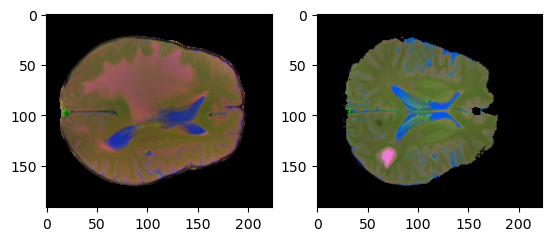

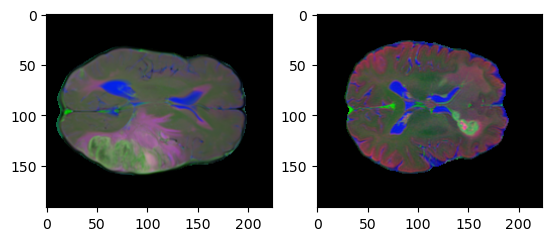

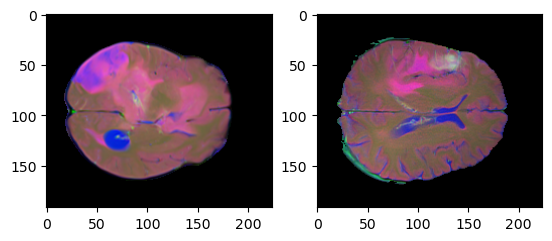

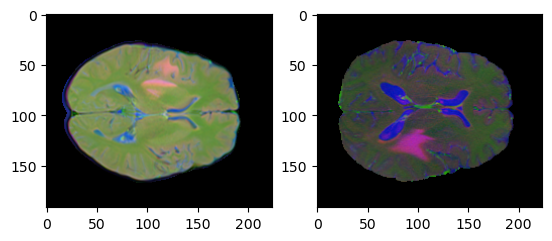

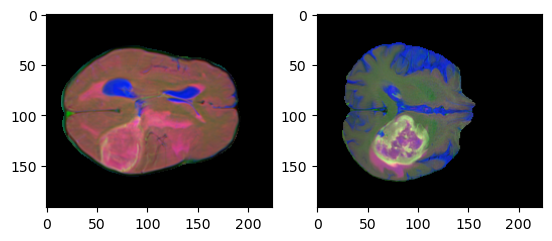

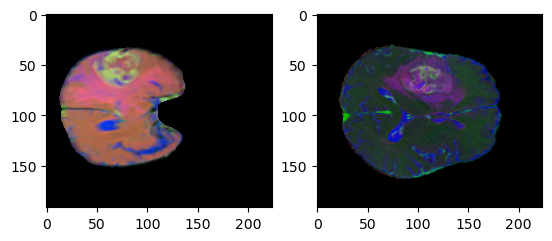

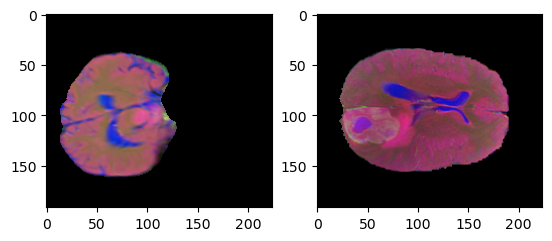

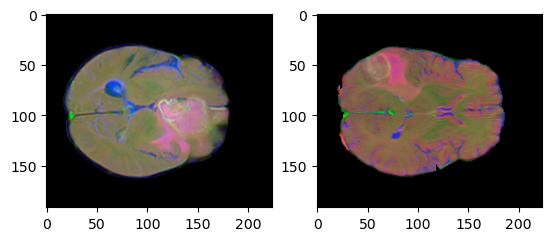

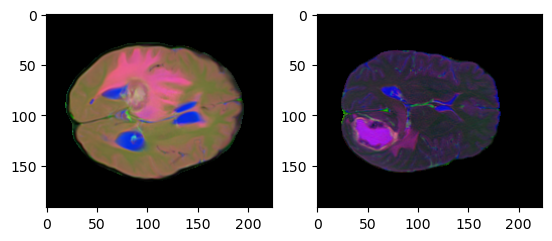

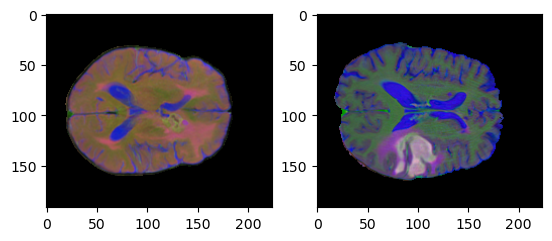

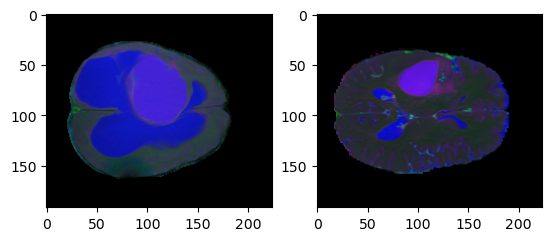

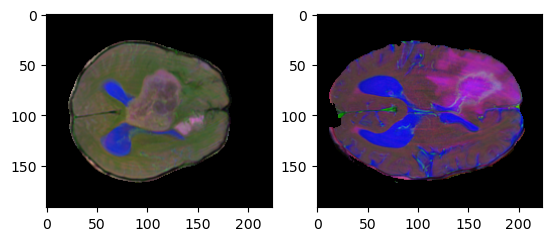

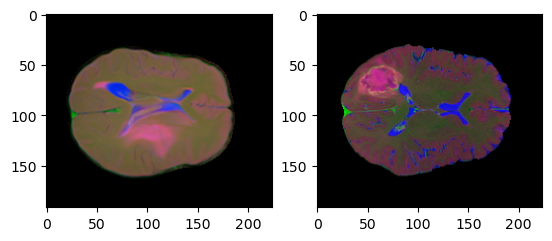

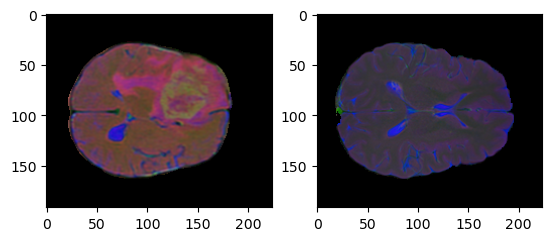

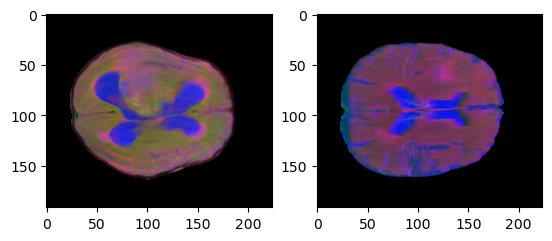

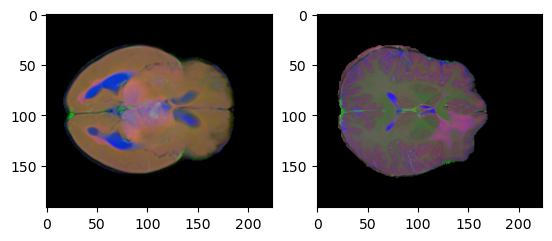

In [39]:
display_img(SSA_image_path, GLI_image_path)

## Full Image Characteristics

In [26]:
_, ssa_image_std, _ = mean_image_std(SSA_image_path) 
_, gli_image_std, _ = mean_image_std(GLI_image_path) 

In [27]:
print(f'This is the mean of the SSA {ssa_image_std.mean()} and this is the mean of GLI {gli_image_std.mean()}')

This is the mean of the SSA 2.0279061794281006 and this is the mean of GLI 2.154754638671875


In [28]:
t_stat, p_val = ttest_ind(ssa_image_std, gli_image_std, equal_var=False)
print(f"t-statistic = {t_stat}, p-value = {p_val}")

t-statistic = -4.778392232418429, p-value = 5.26754511768368e-06


In [12]:
_, ssa_entropy_std, _ = mean_image_entropy(SSA_image_path) 
_, gli_entropy_std, _ = mean_image_entropy(GLI_image_path) 

In [18]:
print(f'This is the mean of the SSA {ssa_entropy_std.mean()} and this is the mean of GLI {gli_entropy_std.mean()}')

This is the mean of the SSA 2.3607217097294737 and this is the mean of GLI 2.1768787707297887


In [21]:
t_stat, p_val = ttest_ind(ssa_entropy_std, gli_entropy_std, equal_var= False)
print(f"t-statistic = {t_stat}, p-value = {p_val}")

t-statistic = 4.707522518070686, p-value = 7.471192900806623e-06


## Tumor - Non Tumor Characteristics

In [73]:
# mean difference
import torch 
def mean_diff(tumour_region, non_tumour_region):
    mean_tumour = tumour_region.mean()
    mean_non_tumour = non_tumour_region.mean()
    mean_diff = abs(mean_tumour - mean_non_tumour)
    return mean_diff

def tumour_diff(img, mask):
    tumour_region = img[mask == 1, :]
    non_tumour_region = img[ mask != 1, :]
    mean_difference = mean_diff(tumour_region, non_tumour_region)
    return mean_difference

def cohens_d(a, b):
    mean_diff = np.mean(a) - np.mean(b)
    pooled_std = np.sqrt(((np.std(a) ** 2) + (np.std(b) ** 2)) / 2)
    return mean_diff / pooled_std

def cohens_diff(img, mask):
    tumour_region = img[mask == 1, :]
    print(f'This is the tumour regiong shape{img.shape,tumour_region.shape}')
    # plt.imshow(tumour_region)
    # plt.show()
    non_tumour_region = img[ mask != 1, :]
    # plt.imshow(non_tumour_region)
    # plt.show()
    mean_difference = cohens_d(tumour_region, non_tumour_region)
    return mean_difference

def tumour_non_tumor_difference(path, dataset):

    sharpness = []
    
    for i in range(len(dataset)):
        # print(i)
        try:
            idx, img, label_name, box, points, frames, label = dataset[i]
            img = vis_image(os.path.join(path, img))
            
            per_class = []
            for i in range(3):
                label_class = label[i]
                label_class = torch.permute(label_class, (2,0,1))
                lap_var = tumour_diff(img,label_class)
                per_class.append(lap_var)
            sharpness.append(per_class)
        except Exception as e:
            print(e)
    sharpness = np.array(sharpness)
    mean_sharpness = sharpness.mean()
    return sharpness, mean_sharpness


def tumour_non_tumor_cohens(path, dataset):

    sharpness = []
    
    for i in range(len(dataset)):
        # print(i)
        try:
            idx, img, label_name, box, points, frames, label = dataset[i]
            img = vis_image(os.path.join(path, img))
            
            per_class = []
            for i in range(3):
                label_class = label[i]
                label_class = torch.permute(label_class, (2,0,1))
                lap_var = cohens_diff(img,label_class)
                per_class.append(lap_var)
            sharpness.append(per_class)
        except Exception as e:
            print(e)
    sharpness = np.array(sharpness)
    mean_sharpness = sharpness.mean()
    return sharpness, mean_sharpness


In [69]:
ssa_tumour_diff = tumour_non_tumor_difference(SSA_image_path, SSA_dataset)
gli_tumour_diff = tumour_non_tumor_difference(GLI_image_path, GLI_dataset)

Best slice with all 3 tumors: 112
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
Best slice with all 3 tumors: 92
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
Best slice with all 3 tumors: 90
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 1

KeyboardInterrupt: 

In [59]:
print(f'This is the mean of the SSA {ssa_tumour_diff[0][2].mean()} and this is the mean of GLI {gli_tumour_diff[0][2].mean()}')

This is the mean of the SSA 0.48417672514915466 and this is the mean of GLI 0.3116741478443146


In [74]:
ssa_tumour_diff = tumour_non_tumor_cohens(SSA_image_path, SSA_dataset)
gli_tumour_diff = tumour_non_tumor_cohens(GLI_image_path, GLI_dataset)

Best slice with all 3 tumors: 112
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
This is the tumour regiong shape((160, 192, 224, 3), (6603, 3))
This is the tumour regiong shape((160, 192, 224, 3), (190334, 3))
This is the tumour regiong shape((160, 192, 224, 3), (21524, 3))
Best slice with all 3 tumors: 92
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
This is the tumour regiong shape((160, 192, 224, 3), (29731, 3))
This is the tumour regiong shape((160, 19

/scratch_net/ken/radjoe/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/scratch_net/ken/radjoe/conda/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/scratch_net/ken/radjoe/conda/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/scratch_net/ken/radjoe/conda/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/scratch_net/ken/radjoe/conda/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


This is the tumour regiong shape((160, 192, 224, 3), (63784, 3))
This is the tumour regiong shape((160, 192, 224, 3), (664, 3))
Best slice with all 3 tumors: 100
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
This is the tumour regiong shape((160, 192, 224, 3), (2118, 3))
This is the tumour regiong shape((160, 192, 224, 3), (10846, 3))
This is the tumour regiong shape((160, 192, 224, 3), (9454, 3))
Best slice with all 3 tumors: 116
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (1

In [65]:
print(f'This is the mean of the SSA {ssa_tumour_diff[0][2].mean()} and this is the mean of GLI {gli_tumour_diff[0][2].mean()}')

This is the mean of the SSA 2.551962411230663 and this is the mean of GLI 1.747230484846743


## Quantify Sharpness

### Laplacian Sharpness

In [44]:
_ , ssa_lap, ssa_mean_lap = mean_laplacian_sharpness(SSA_image_path)
_ , gli_lap, gli_mean_lap = mean_laplacian_sharpness(GLI_image_path)

print(f'The mean sharpness for SSA is {ssa_mean_lap} and {gli_mean_lap}')

The mean sharpness for SSA is 504.3664977058532 and 574.8372341579859


In [45]:
t_stat, p_val = ttest_ind(ssa_lap, gli_lap, equal_var=False)
print(f"t-statistic = {t_stat}, p-value = {p_val}")

t-statistic = -1.534392512817673, p-value = 0.12765746691431065


In [46]:
from scipy.stats import mannwhitneyu
u_stat, p_val_u = mannwhitneyu(ssa_lap, gli_lap, alternative='two-sided')
print(f"U-statistic = {u_stat}, p-value = {p_val_u}")

U-statistic = 1445.0, p-value = 0.06279468473018224


In [48]:
from itertools import product

def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    more = sum(1 for xi, yi in product(x, y) if xi > yi)
    less = sum(1 for xi, yi in product(x, y) if xi < yi)
    delta = (more - less) / (nx * ny)
    
    # Effect size interpretation
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        magnitude = "negligible"
    elif abs_delta < 0.33:
        magnitude = "small"
    elif abs_delta < 0.474:
        magnitude = "medium"
    else:
        magnitude = "large"
        
    return delta, magnitude

In [49]:

d, res = cliffs_delta(ssa_lap, gli_lap)
print(f"Cliff’s delta: {d} ({res})")

Cliff’s delta: -0.19722222222222222 (small)


### Laplacian Sharpness

In [51]:
_ , ssa_lap, ssa_mean_lap = mean_tenen_sharpness(SSA_image_path)
_ , gli_lap, gli_mean_lap = mean_tenen_sharpness(GLI_image_path)

print(f'The mean sharpness for SSA is {ssa_mean_lap} and {gli_mean_lap}')

The mean sharpness for SSA is 30.137580157913938 and 28.7583288140334


In [52]:
t_stat, p_val = ttest_ind(ssa_lap, gli_lap, equal_var=False)
print(f"t-statistic = {t_stat}, p-value = {p_val}")

t-statistic = 1.782417405958331, p-value = 0.07727160438334436


In [53]:
from scipy.stats import mannwhitneyu
u_stat, p_val_u = mannwhitneyu(ssa_lap, gli_lap, alternative='two-sided')
print(f"U-statistic = {u_stat}, p-value = {p_val_u}")

U-statistic = 2205.0, p-value = 0.033747617925244416


In [56]:
_ , ssa_lap, ssa_mean_lap = mean_fft_sharpness(SSA_image_path)
_ , gli_lap, gli_mean_lap = mean_fft_sharpness(GLI_image_path)

print(f'The mean sharpness for SSA is {ssa_mean_lap} and {gli_mean_lap}')

The mean sharpness for SSA is 137.42984484929175 and 139.7585131084664


- It seems that image quality wise, its comparable

## Quantifying Boundary Sharpness

In [189]:
from scipy.ndimage import binary_dilation

def boundary_band(mask, band_width=4):
    outer = binary_dilation(mask, iterations=band_width)
    inner = binary_dilation(mask, iterations=1)
    return outer & ~inner


def tenengrad_sharpness(image, mask=None):
    # Convert to grayscale if necessary
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    # Compute Sobel gradients
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    grad_magnitude_sq = gx**2 + gy**2

    if mask is not None:
        return np.mean(grad_magnitude_sq[mask > 0])
    else:
        return np.mean(grad_magnitude_sq)
    
def sharpness_on_edges(img, mask):
    band = boundary_band(mask)
    # plt.imshow(band)
    # plt.show()
    lap = tenengrad_sharpness(img, band)
    return lap

def boundary_laplacian_sharpness(path, dataset):

    sharpness = []
    
    for i in range(len(dataset)):
        # print(i)
        try:
            idx, img, label_name, box, points, frames, label = dataset[i]
            img = vis_image(os.path.join(path, img))
            img = img[frames]
            print(img.shape)

            label = label[:,:,:,frames]
            if len(img.shape) == 3 and img.shape[2] == 3:
                img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
                # Normalize dtype
            if img.dtype != np.uint8:
                img = cv2.normalize(img.astype('float32'), None, 0, 255, cv2.NORM_MINMAX)
                img = img.astype(np.uint8)
            per_class = []
            for i in range(3):
                lap_var = sharpness_on_edges(img,label[i])
                per_class.append(lap_var)
            sharpness.append(per_class)
        except:
            pass
    sharpness = np.array(sharpness)
    mean_sharpness = sharpness.mean()
    return sharpness, mean_sharpness

In [190]:
ssa_lap, ssa_mean_lap = boundary_laplacian_sharpness(SSA_image_path, SSA_dataset)
gli_lap, gli_mean_lap = boundary_laplacian_sharpness(GLI_image_path, GLI_dataset)

print(f'The mean sharpness for SSA is {ssa_mean_lap} and {gli_mean_lap}')

Best slice with all 3 tumors: 112
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(192, 224, 3)
Best slice with all 3 tumors: 92
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(192, 224, 3)
Best slice with all 3 tumors: 90
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1)

/scratch_net/ken/radjoe/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/scratch_net/ken/radjoe/conda/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Best slice with all 3 tumors: 100
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(192, 224, 3)
Best slice with all 3 tumors: 116
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(192, 224, 3)
Best slice with all 3 tumors: 94
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1

In [191]:
ssa_lap_df = pd.DataFrame(ssa_lap)

In [192]:
gli_lap_df = pd.DataFrame(gli_lap)

In [193]:
ssa_lap_df.mean()

0     8336.363708
1    12136.841061
2     5808.264761
dtype: float64

In [194]:
gli_lap_df.mean()

0    22876.663316
1    20171.810325
2     9586.861955
dtype: float64

## Correlation between Performance and Boundary Sharpness

In [195]:
# load data 
MedSAM_path_box = '../results_med/BraTS_SSA/MedSAM2/SSA_boxes.csv'
MedSAM_df_box_unclean =  pd.read_csv(MedSAM_path_box)
# MedSAM_df_box = clean_df(MedSAM_df_box_unclean, True, 'brats')

In [196]:
GLI_MedSAM_path_box = '../results_med/BraTS_GLI/MedSAM2/SSA_boxes.csv'
GLI_MedSAM_df_box_unclean =  pd.read_csv(GLI_MedSAM_path_box)

In [197]:
GLI_MedSAM_df_box =  clean_df(GLI_MedSAM_df_box_unclean, True, 'brats')

In [198]:
GLI_MedSAM_df_box.describe()

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET
count,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,0.489476,0.520707,0.621113,9.886622,16.016758,10.378545
std,0.227931,0.215530,0.203004,5.388128,14.689955,6.557112
min,0.060519,0.034721,0.033684,1.892814,5.099020,3.000000
25%,0.288938,0.338905,0.503323,6.557438,9.000000,5.916080
50%,0.518356,0.576889,0.640956,9.200508,10.779603,7.874008
75%,0.660879,0.668310,0.780386,11.846908,13.601471,11.000000
max,0.889496,0.846029,0.901705,30.324898,84.972343,29.676582


In [199]:
GLI_MedSAM_df_box_unclean
GLI_MedSAM_df_box_unclean = GLI_MedSAM_df_box_unclean.drop(columns = [GLI_MedSAM_df_box_unclean.columns[0]])

In [200]:
GLI_MedSAM_df_box_unclean

,0,1,2,3,4,5,6
0,BraTS-GLI-00016-000.npy,0.672473,0.505870,0.606754,6.000000,9.219544,5.000000
1,BraTS-GLI-00036-001.npy,0.731039,0.648458,0.548350,7.000000,9.000000,7.000000
2,BraTS-GLI-00043-000.npy,0.773565,0.841818,0.416754,7.000000,10.862781,5.744563
3,BraTS-GLI-00064-000.npy,0.535333,0.569902,0.564277,9.433981,7.141428,7.615773
4,BraTS-GLI-00090-001.npy,0.535207,0.845438,0.770226,5.440399,12.206555,5.744563
5,BraTS-GLI-00165-000.npy,0.660879,0.780529,0.627198,12.041595,9.000000,5.916080
6,BraTS-GLI-00172-000.npy,0.448926,0.724827,0.640956,10.049875,11.357817,11.000000
7,BraTS-GLI-00196-000.npy,0.249905,0.576889,0.895608,23.622025,46.716148,7.874008
8,BraTS-GLI-00203-000.npy,0.615958,0.598052,0.494312,10.954452,10.709751,9.433981
9,BraTS-GLI-00235-000.npy,0.860268,0.625967,0.529656,3.316625,6.403124,3.605551


In [201]:
MedSAM_df_box_unclean
MedSAM_df_box_unclean = MedSAM_df_box_unclean.drop(columns = [MedSAM_df_box_unclean.columns[0]])

In [202]:
MedSAM_df_box_unclean

,0,1,2,3,4,5,6
0,BraTS-SSA-00002-000.npy,0.151512,0.790172,0.388256,72.612671,49.767448,66.425903
1,BraTS-SSA-00007-000.npy,0.431649,0.625285,0.581711,30.413813,27.748875,38.131351
2,BraTS-SSA-00008-000.npy,0.599540,0.558356,0.484618,11.930851,14.352700,12.845233
3,BraTS-SSA-00010-000.npy,0.618051,0.507676,0.480530,13.674794,9.219544,12.845233
4,BraTS-SSA-00011-000.npy,0.815080,0.765957,0.435841,10.440307,11.401754,5.477226
5,BraTS-SSA-00012-000.npy,0.650607,0.731663,0.709152,10.049875,13.076696,9.380832
6,BraTS-SSA-00014-000.npy,0.458780,0.839921,0.645411,21.000000,7.874008,12.000000
7,BraTS-SSA-00015-000.npy,0.890427,0.518482,0.338538,4.898980,13.453624,5.477226
8,BraTS-SSA-00025-000.npy,0.549904,0.308846,0.454542,23.259407,31.575306,13.747727
9,BraTS-SSA-00026-000.npy,0.264523,0.273015,0.490326,8.602325,41.303753,20.273134


In [203]:
ssa_lap_df

,0,1,2
0,3782.990826,1989.809181,1528.393333
1,4835.561644,8639.550922,2275.987867
2,4326.615034,2096.000000,4000.279883
3,6321.431542,19363.562158,4263.536744
4,10023.262599,5340.712242,1366.761236
5,20092.907801,13618.623834,1661.538462
6,1562.894737,3663.120408,4811.758333
7,2674.438449,2853.164761,720.343008
8,2782.911290,4019.437661,1753.660978
9,1510.170732,4744.702589,4334.425641


In [204]:
corr_ssa = pd.concat([MedSAM_df_box_unclean, ssa_lap_df], axis=1)
corr_ssa.columns = ['name', 'dice_NCR', 'dice_ED', 'dice_ET', 'hausdorff_NCR', 'hausdorff_ED', 'hausdorff_ET', 'sharp_NCR', 'sharp_ED', 'sharp_ET']

In [205]:
corr_gli = pd.concat([GLI_MedSAM_df_box_unclean, gli_lap_df], axis=1)
corr_gli.columns = ['name', 'dice_NCR', 'dice_ED', 'dice_ET', 'hausdorff_NCR', 'hausdorff_ED', 'hausdorff_ET', 'sharp_NCR', 'sharp_ED', 'sharp_ET']

In [211]:
corr_gli.drop(columns=['name'])[corr_gli.columns[4::]].corr('spearman')

,hausdorff_NCR,hausdorff_ED,hausdorff_ET,sharp_NCR,sharp_ED,sharp_ET
hausdorff_NCR,1.000000,0.202769,0.615397,-0.301264,-0.359514,-0.215527
hausdorff_ED,0.202769,1.000000,0.106790,-0.061315,0.044600,-0.044424
hausdorff_ET,0.615397,0.106790,1.000000,-0.309515,-0.117666,0.097232
sharp_NCR,-0.301264,-0.061315,-0.309515,1.000000,0.199852,0.181334
sharp_ED,-0.359514,0.044600,-0.117666,0.199852,1.000000,0.384863
sharp_ET,-0.215527,-0.044424,0.097232,0.181334,0.384863,1.000000


In [212]:
corr_ssa.drop(columns=['name'])[corr_ssa.columns[4::]].corr('spearman')

,hausdorff_NCR,hausdorff_ED,hausdorff_ET,sharp_NCR,sharp_ED,sharp_ET
hausdorff_NCR,1.000000,0.264967,0.543805,-0.111113,-0.022413,-0.035793
hausdorff_ED,0.264967,1.000000,0.254651,0.131498,0.015005,-0.126987
hausdorff_ET,0.543805,0.254651,1.000000,0.101171,0.250968,0.316991
sharp_NCR,-0.111113,0.131498,0.101171,1.000000,0.381818,0.222799
sharp_ED,-0.022413,0.015005,0.250968,0.381818,1.000000,0.386107
sharp_ET,-0.035793,-0.126987,0.316991,0.222799,0.386107,1.000000


In [209]:
total = pd.concat([corr_ssa , corr_gli], axis=0)

In [215]:
total.drop(columns=['name']).corr('spearman')

,dice_NCR,dice_ED,dice_ET,hausdorff_NCR,hausdorff_ED,hausdorff_ET,sharp_NCR,sharp_ED,sharp_ET
dice_NCR,1.000000,-0.111264,-0.191771,-0.431367,-0.199140,-0.218435,0.171802,0.173931,0.014817
dice_ED,-0.111264,1.000000,0.014827,-0.040973,-0.352635,-0.114853,-0.143132,0.065981,-0.174192
dice_ET,-0.191771,0.014827,1.000000,-0.270371,-0.090508,-0.522571,0.186539,0.041333,0.012719
hausdorff_NCR,-0.431367,-0.040973,-0.270371,1.000000,0.312157,0.632062,-0.372747,-0.330918,-0.203677
hausdorff_ED,-0.199140,-0.352635,-0.090508,0.312157,1.000000,0.262103,-0.110334,-0.117974,-0.184520
hausdorff_ET,-0.218435,-0.114853,-0.522571,0.632062,0.262103,1.000000,-0.210632,-0.032254,0.121245
sharp_NCR,0.171802,-0.143132,0.186539,-0.372747,-0.110334,-0.210632,1.000000,0.465691,0.366633
sharp_ED,0.173931,0.065981,0.041333,-0.330918,-0.117974,-0.032254,0.465691,1.000000,0.459144
sharp_ET,0.014817,-0.174192,0.012719,-0.203677,-0.184520,0.121245,0.366633,0.459144,1.000000


In [217]:
t_stat, p_val = ttest_ind(total['hausdorff_NCR'].dropna(), total['sharp_NCR'].dropna(), equal_var=False)
print(f"t-statistic = {t_stat}, p-value = {p_val}")

t-statistic = -12.341324070541198, p-value = 1.2921008887174526e-22


In [313]:
from scipy.ndimage import gaussian_filter

def blur_boundary(image, mask, sigma=1.5, band_width=3):
    """
    Blur boundary regions in a 4D image [C, D, H, W] using a 3D mask [D, H, W]
    """
    from scipy.ndimage import gaussian_filter, binary_dilation, binary_erosion

    # Compute boundary region
    dilated = binary_dilation(mask, iterations=band_width)
    eroded = binary_erosion(mask, iterations=band_width)
    boundary = dilated & ~eroded  # shape: [D, H, W]

    # If image has channels, apply per channel
    result = np.copy(image)
    for c in range(image.shape[0]):
        blurred = gaussian_filter(image[c], sigma=sigma)
        result[c][boundary] = blurred[boundary]
    return result

In [320]:
def blur_img(path, dataset, save_path):
    for i in range(len(dataset)):
        # print(i)
        # try:
            idx, img, label_name, box, points, frames, label = dataset[i]
            img_name = img
            # img_vis = vis_image()
            # img_vis = img_vis[frames]
            img2 = np.load(os.path.join(path, img))
            print(img2.shape)

    
            # print(label.shape)
            # if len(img2.shape) == 3 and img2.shape[2] == 3:
            #     img2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
            #     # Normalize dtype
            # if img2.dtype != np.uint8:
            #     img2 = cv2.normalize(img2.astype('float32'), None, 0, 255, cv2.NORM_MINMAX)
            #     img2 = img2.astype(np.uint8)
            img1 = np.copy(img2)

            img1 = blur_boundary(img1, label[0])
            img1 = blur_boundary(img1, label[1])
            img1 = blur_boundary(img1, label[2])
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(np.transpose(img2[[0,2,3],:,:, frames], ( 1, 2,0)))
            ax[1].imshow(np.transpose(img1[[0,2,3],:,:, frames], ( 1, 2,0)))
            plt.show()
            np.save(f'{save_path}/{img_name}', img1)
        # except Exception as e:
            # print(e)

In [321]:
path = '/scratch/radjoe/BraTS/Blurred'

Best slice with all 3 tumors: 72
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6293182..10.740682].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6293182..10.740682].


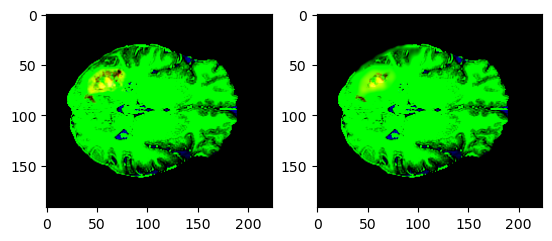

Best slice with all 3 tumors: 84
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.695067..5.310424].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.695067..5.310424].


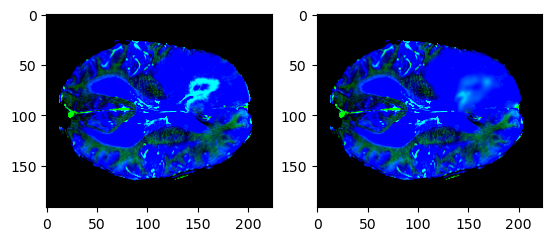

Best slice with all 3 tumors: 48
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4735117..11.361897].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4735117..11.361897].


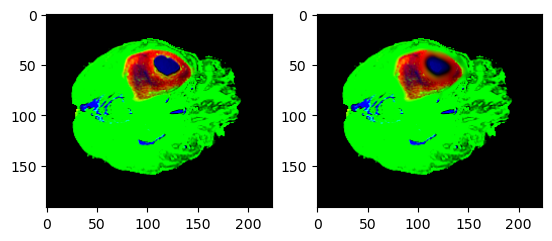

Best slice with all 3 tumors: 76
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5209253..14.945781].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5209253..14.945781].


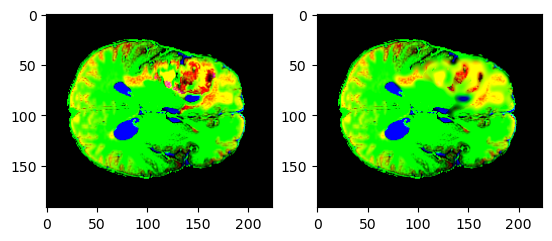

Best slice with all 3 tumors: 66
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3128698..12.000244].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3128698..12.000244].


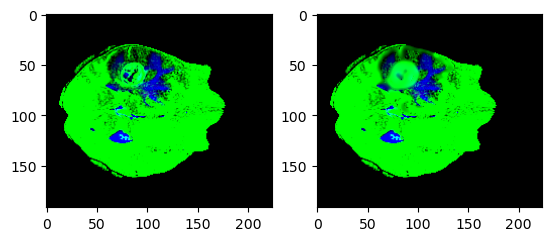

Best slice with all 3 tumors: 98
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.702129..6.268736].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.702129..6.1185255].


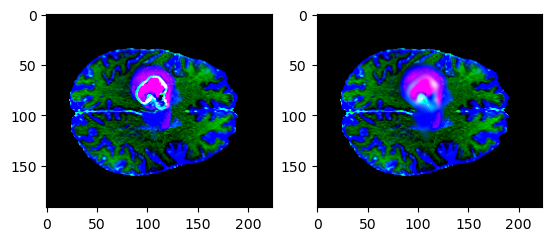

Best slice with all 3 tumors: 71
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9665612..6.3917055].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9665612..6.3917055].


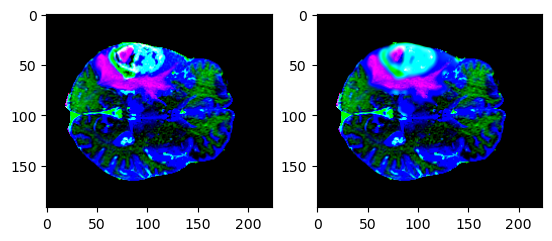

Best slice with all 3 tumors: 106
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7320769..6.360498].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7320769..5.9043794].


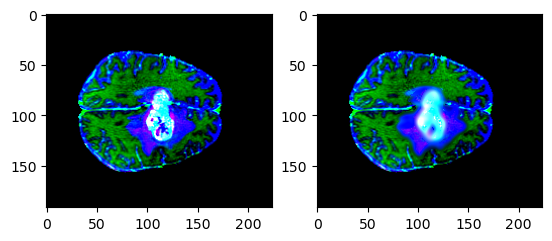

Best slice with all 3 tumors: 73
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.757577..6.793864].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.757577..6.793864].


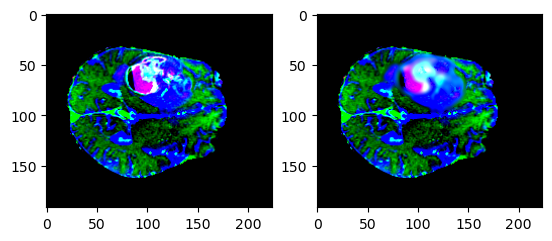

Best slice with all 3 tumors: 92
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9812127..6.690129].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9812127..6.68409].


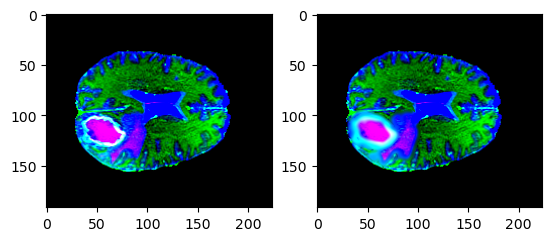

Best slice with all 3 tumors: 56
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1956859..5.5279946].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1956859..5.5279946].


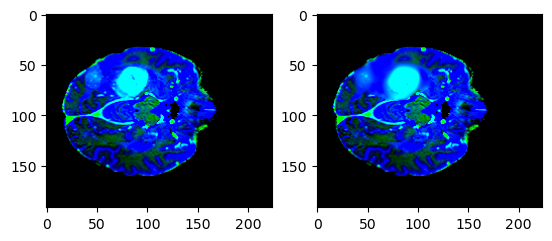

Best slice with all 3 tumors: 65
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8687683..7.004906].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8687683..7.004906].


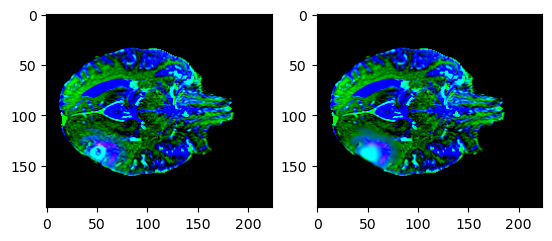

Best slice with all 3 tumors: 68
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.666701..7.0571365].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.666701..6.8116293].


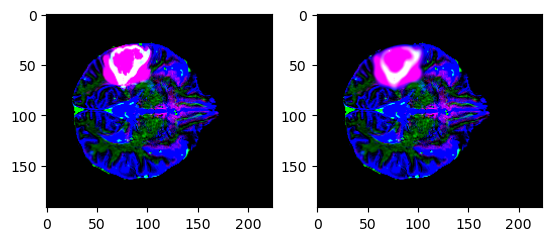

Best slice with all 3 tumors: 85
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0392935..8.55142].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0392935..7.7720857].


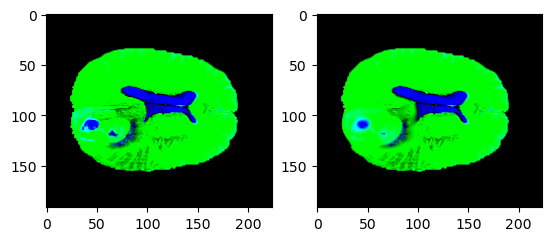

Best slice with all 3 tumors: 81
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.889352..5.1260114].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.889352..5.1260114].


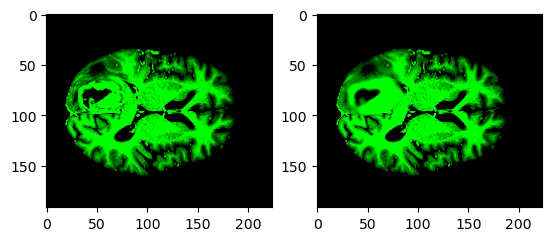

Best slice with all 3 tumors: 98
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.018479..7.242967].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.018479..6.911359].


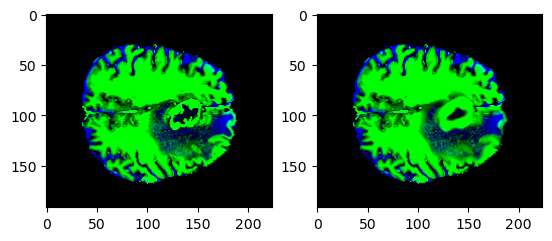

Best slice with all 3 tumors: 95
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3223218..10.3708725].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3223218..10.3708725].


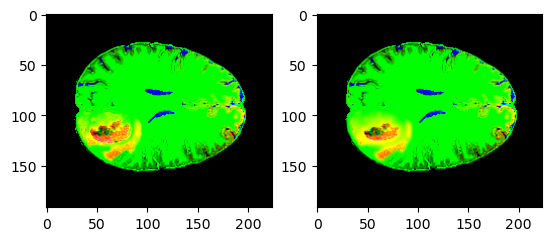

Best slice with all 3 tumors: 86
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6124445..5.573809].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6124445..5.573809].


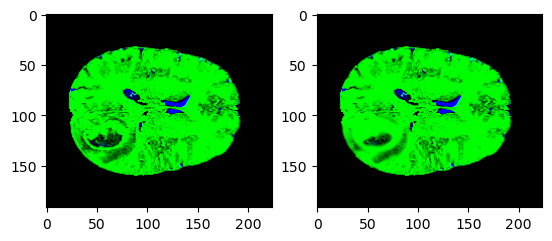

Best slice with all 3 tumors: 67
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.4625213..5.9169374].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.4625213..5.0712485].


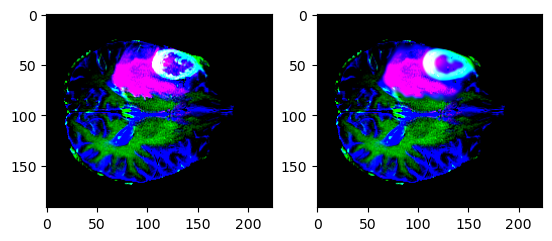

Best slice with all 3 tumors: 70
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4916862..9.915747].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4916862..9.915747].


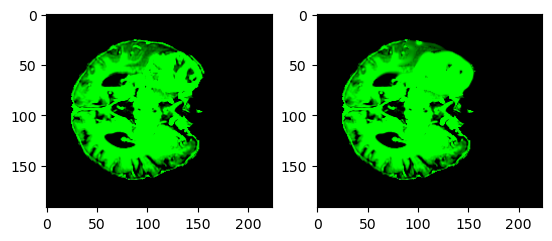

Best slice with all 3 tumors: 49
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6282066..9.466585].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6282066..9.466585].


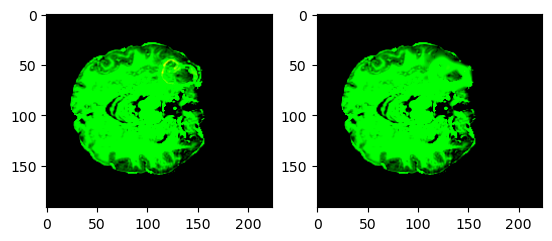

Best slice with all 3 tumors: 104
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.6317186..5.6422763].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.6317186..5.6422763].


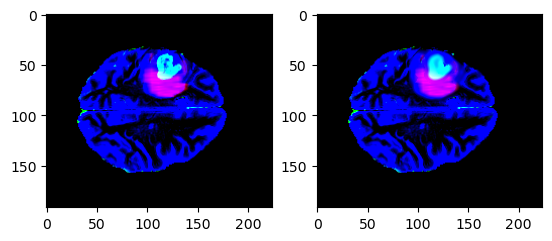

Best slice with all 3 tumors: 114
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4904218..13.444309].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4904218..13.444309].


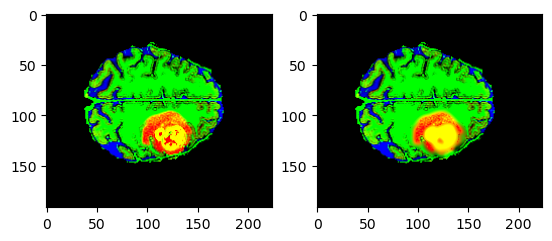

Best slice with all 3 tumors: 70
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9253929..7.687299].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9253929..7.687299].


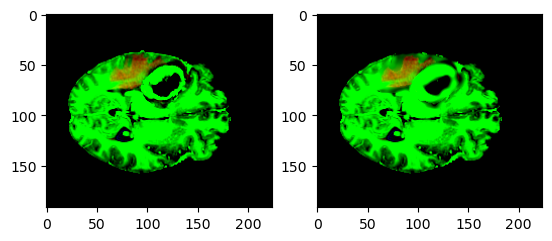

Best slice with all 3 tumors: 92
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2756153..6.032657].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2756153..6.032657].


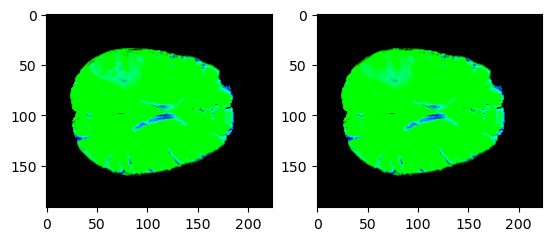

Best slice with all 3 tumors: 104
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9610716..7.1432247].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9610716..6.6340737].


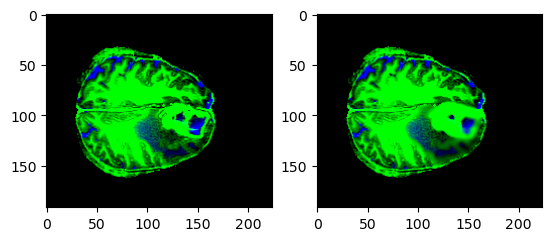

Best slice with all 3 tumors: 90
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.6597362..8.490036].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.6597362..8.490036].


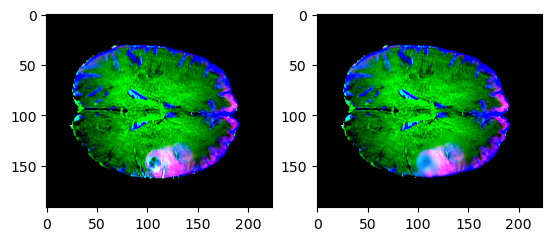

Best slice with all 3 tumors: 92
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6385415..7.0097513].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6385415..7.0097513].


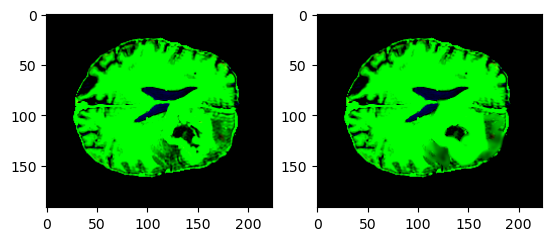

Best slice with all 3 tumors: 70
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4678996..6.191666].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4678996..6.191666].


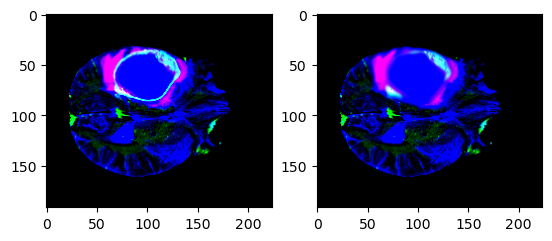

Best slice with all 3 tumors: 109
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0018382..5.360993].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0018382..5.360993].


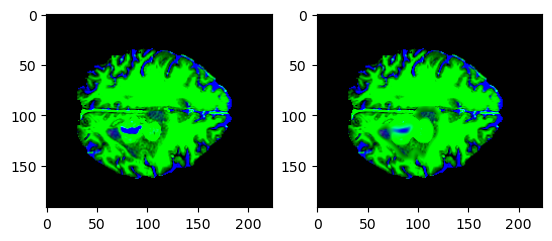

Best slice with all 3 tumors: 117
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5000765..7.072786].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5000765..7.072786].


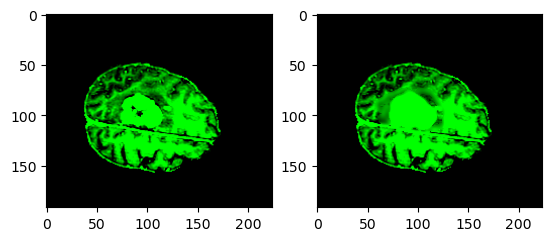

Best slice with all 3 tumors: 84
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4903897..7.7217126].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4903897..7.7217126].


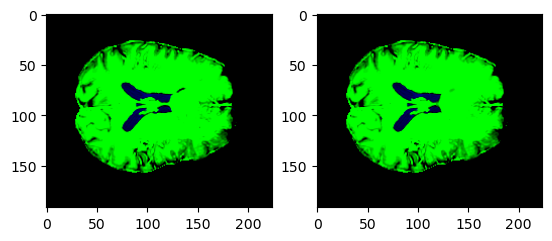

No slice contains all 3 tumor classes.
Print the 2 classes tensor([62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79,
        80, 81, 82, 83, 84, 85, 86, 87])
Best slice with all 2 tumors: 75
Best slice with all 3 tumors: 75
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.043038..5.505307].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.043038..5.505307].


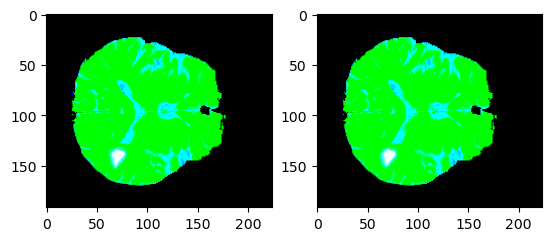

Best slice with all 3 tumors: 106
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.683688..6.4738765].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.683688..6.4738765].


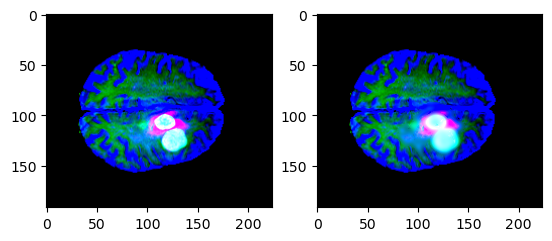

Best slice with all 3 tumors: 98
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6122085..9.605746].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6122085..9.605746].


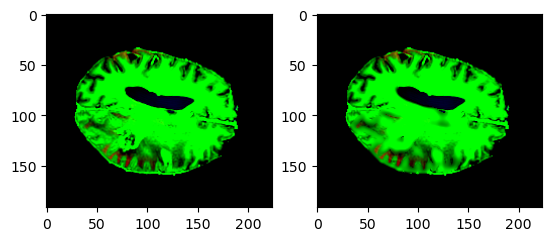

Best slice with all 3 tumors: 97
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7403753..9.01398].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7403753..9.01398].


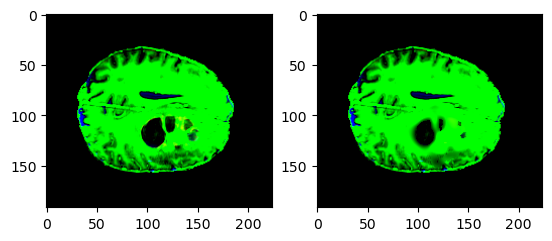

Best slice with all 3 tumors: 87
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1076934..5.4428716].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1076934..5.4428716].


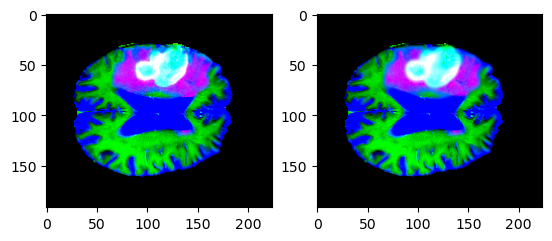

Best slice with all 3 tumors: 62
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.2105641..8.37064].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.2105641..8.146849].


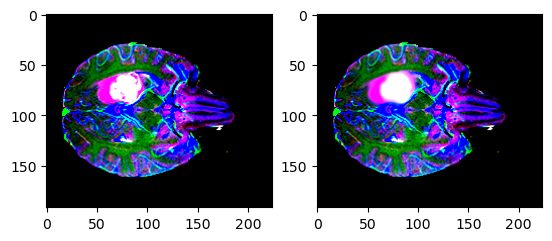

Best slice with all 3 tumors: 105
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1176052..5.6355386].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1176052..5.3595867].


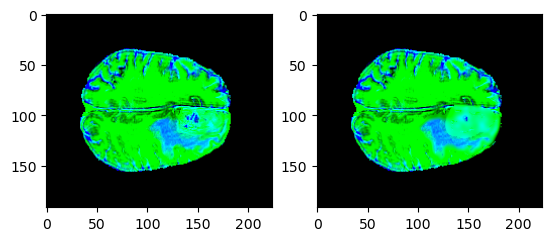

Best slice with all 3 tumors: 64
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5134673..5.702986].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5134673..5.702986].


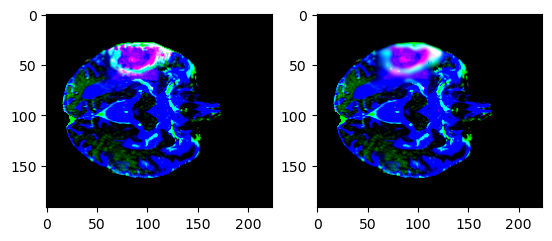

Best slice with all 3 tumors: 65
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7217016..5.4273896].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7217016..5.4273896].


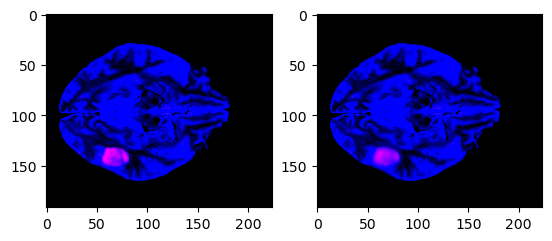

Best slice with all 3 tumors: 77
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4652864..12.634652].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4652864..12.634652].


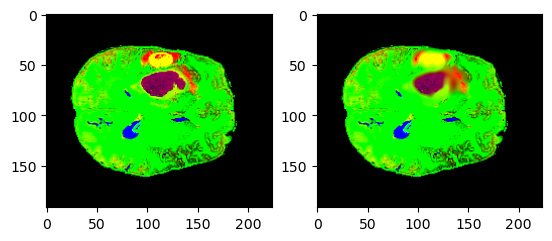

Best slice with all 3 tumors: 88
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7402755..11.051001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7402755..11.051001].


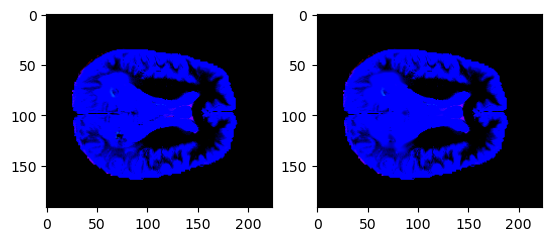

Best slice with all 3 tumors: 70
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0866234..12.38423].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0866234..12.38423].


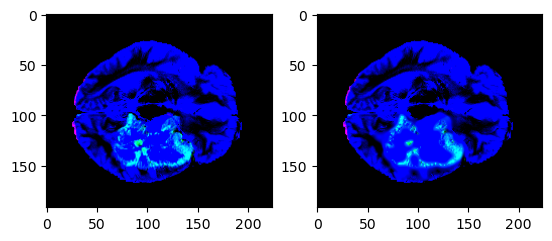

Best slice with all 3 tumors: 56
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7739066..10.036364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7739066..10.036364].


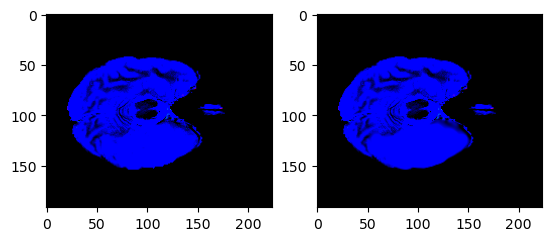

Best slice with all 3 tumors: 94
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9300299..11.541832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9300299..11.541832].


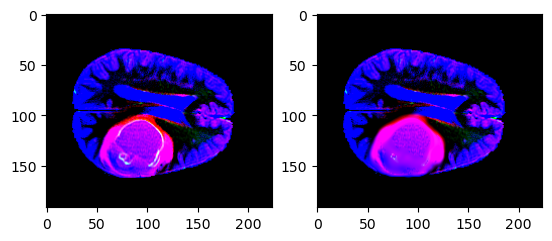

Best slice with all 3 tumors: 59
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0783348..9.267647].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0783348..9.267647].


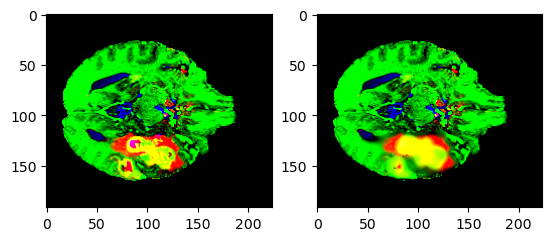

Best slice with all 3 tumors: 86
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0783432..11.315046].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0783432..11.315046].


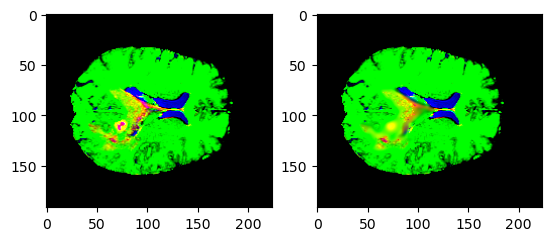

Best slice with all 3 tumors: 75
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9912715..7.6861944].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9912715..7.6861944].


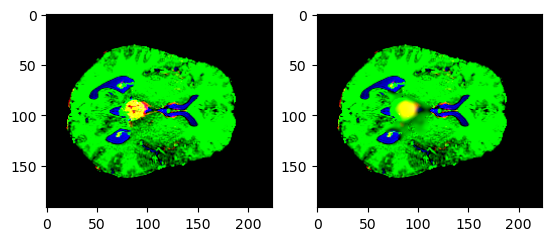

Best slice with all 3 tumors: 128
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9250579..6.3129673].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9250579..6.3129673].


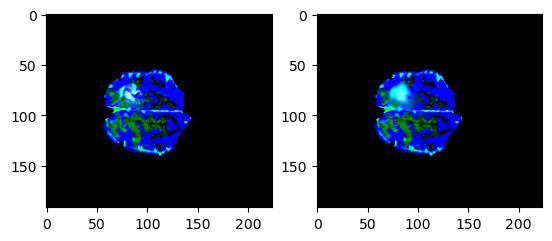

Best slice with all 3 tumors: 110
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8514705..7.347246].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8514705..7.347246].


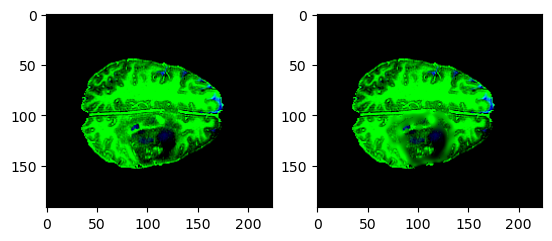

Best slice with all 3 tumors: 77
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.999245..5.0800686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.999245..5.0800686].


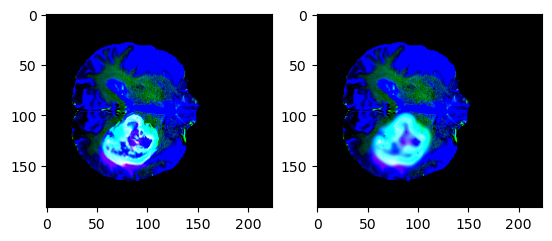

Best slice with all 3 tumors: 52
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.238562..6.516931].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.238562..6.516931].


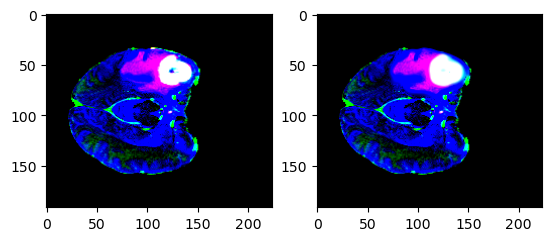

Best slice with all 3 tumors: 95
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117202..5.4494762].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117202..5.4494762].


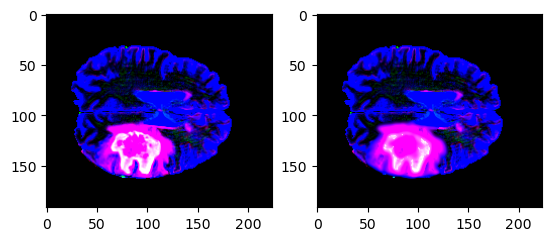

Best slice with all 3 tumors: 59
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7504914..8.705397].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7504914..8.416102].


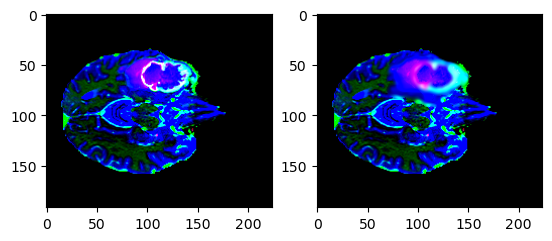

Best slice with all 3 tumors: 81
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2603168..7.0606074].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2603168..7.0606074].


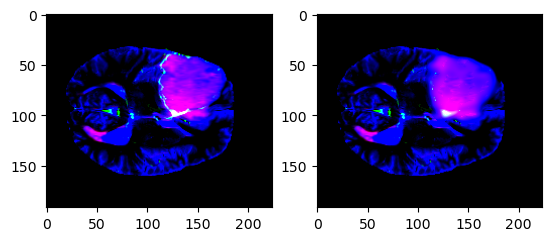

Best slice with all 3 tumors: 61
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3357882..7.586969].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3357882..7.586969].


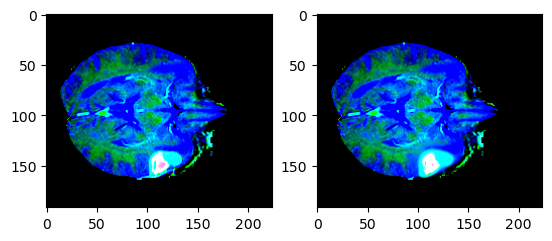

Best slice with all 3 tumors: 54
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5651147..4.5144477].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5651147..4.5144477].


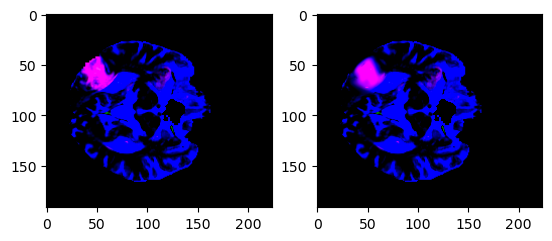

Best slice with all 3 tumors: 93
[[(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)], [(-1, -1), (-1, -1), (-1, -1), (-1, -1), (-1, -1), (17, 187), (128, 32), (71, 7), (104, 80), (145, 71)]]
(4, 192, 224, 160)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.139384..6.0870624].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.139384..6.0870624].


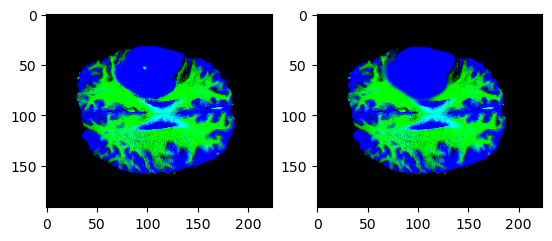

EOFError: No data left in file

In [322]:
blur_img(GLI_image_path, GLI_dataset, path )